# Ablation Study — Stage 1: Regime Identification

**Experimentos:** A1 (Jump Penalty λ) · A2 (Volatility Estimator) · A3 (Número de Regimes k)

Este notebook implementa os ablations do Stage 1 do pipeline JM-XGB, analisando como cada
escolha de design na identificação de regimes impacta:
- **ADD** (Average Detection Delay) — latência na detecção de mudanças
- **FAR** (False Alarm Ratio) — alarmes falsos durante períodos estáveis
- **Miss Rate** — mudanças reais não detectadas dentro da janela de tolerância
- **CP Accuracy / CP Balanced Accuracy** — acerto da detecção de changepoints nas versões original e balanceada
- **State Accuracy / State Balanced Accuracy** — acerto ponto a ponto das labels de regime nas versões original e balanceada
- **ARI** — estabilidade entre estimações consecutivas

Protocolo: Demšar (2006) — Friedman test + Wilcoxon signed-rank + correção Holm

**JIT:** Funções críticas compiladas com Numba  
**Polars:** Todos os resultados e análises em Polars DataFrames

In [1]:
import sys
from pathlib import Path

# Adiciona o root do projeto ao path
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import logging
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.notebook import tqdm

# Módulos do projeto base
from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor
from src.config.settings import (
    ASSETS, TEST_START, TEST_END,
    ASSET_TICKERS, DATA_START, DATA_END, FRED_SERIES,
)

# Módulos do ablation study
from src.ablation.ablation_runner import (
    AblationConfig, run_single_ablation, prepare_ablation_data,
    ABLATION_A1_CONFIGS, ABLATION_A2_CONFIGS, ABLATION_A3_CONFIGS,
    BASELINE_CONFIG, analyze_ablation, get_component_name,
)
from src.ablation.jit_metrics import compute_add_jit, sortino_ratio_jit, miss_rate_jit
from src.ablation.volatility_estimators import (
    rolling_close_to_close, rolling_parkinson,
    rolling_garman_klass, rolling_rogers_satchell, rolling_yang_zhang,
    ESTIMATOR_NAMES,
)
from src.ablation.regime_diagnostics import regime_diagnostics_summary
from src.ablation.statistical_tests import (
    friedman_test, pairwise_comparison_table, holm_correction,
)
from src.ablation.polars_utils import (
    build_ablation_summary, format_metrics_table, float_nan_to_null,
)

logging.basicConfig(level=logging.WARNING)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✓ Imports concluídos')
print(f'Polars versão: {pl.__version__}')

✓ Imports concluídos
Polars versão: 1.40.1


## 1. Carregamento de Dados

In [2]:
# Carrega e pré-processa dados usando a infraestrutura existente do projeto
loader = DataLoader(cache_dir=str(ROOT / 'data' / 'raw'))
prices = loader.load_prices(ASSET_TICKERS, start=DATA_START, end=DATA_END)
fred_raw = loader.load_fred(FRED_SERIES, start=DATA_START, end=DATA_END)

preprocessor = DataPreprocessor()
er, rf, fred_aligned = preprocessor.prepare(prices, fred_raw)

print(f'Período: {er.index[0].date()} → {er.index[-1].date()}')
print(f'Assets: {er.columns.tolist()}')
print(f'Observações: {len(er):,}')

# Para o ablation, usamos o período de teste definido nas configurações
er_test  = er.loc[TEST_START:TEST_END]
rf_test  = rf.loc[TEST_START:TEST_END]
print(f'\nPeríodo de teste: {er_test.index[0].date()} → {er_test.index[-1].date()} ({len(er_test)} obs)')

Período: 2000-05-22 → 2023-12-29
Assets: ['LargeCap', 'MidCap', 'SmallCap', 'EAFE', 'EM', 'AggBond', 'Treasury', 'HighYield', 'Corporate', 'REIT', 'Commodity', 'Gold']
Observações: 5,940

Período de teste: 2007-01-03 → 2023-12-29 (4278 obs)


In [3]:
# Pré-computa dados OHLC e features para os ativos (cache em memória)
# Estudo completo: todos os 12 ativos do protocolo
DEMO_ASSETS = ASSETS

ohlc_cache = {}
features_cache = {}
vol_cache = {}
true_regimes_cache = {}

print('Preparando dados por ativo...')
for asset in tqdm(DEMO_ASSETS):
    ohlc, features, vol_estimators, true_regimes = prepare_ablation_data(
        asset=asset,
        er=er,
        rf=rf,
        fred=fred_aligned,
    )
    ohlc_cache[asset]         = ohlc
    features_cache[asset]     = features
    vol_cache[asset]          = vol_estimators
    true_regimes_cache[asset] = true_regimes

print(f'✓ Dados preparados para {len(DEMO_ASSETS)} ativos')

# Warm-up do JIT (compila as funções na primeira chamada)
print('Compilando funções JIT (Numba warm-up)...')
_dummy = np.random.randn(100).astype(np.float64)
_ = sortino_ratio_jit(_dummy)
_demo_true = np.array([0,0,1,1,0], dtype=np.int64)
_demo_pred = np.array([0,1,1,1,0], dtype=np.int64)
_ = compute_add_jit(_demo_true, _demo_pred)
_ = miss_rate_jit(_demo_true, _demo_pred)
print('✓ JIT compilado')

Preparando dados por ativo...


  0%|          | 0/12 [00:00<?, ?it/s]

✓ Dados preparados para 12 ativos
Compilando funções JIT (Numba warm-up)...
✓ JIT compilado


## Metodologia de Detecção

Seja `y_t` o regime de referência e `\hat{y}_t` o regime previsto. Definimos a série binária de changepoints por `c_t = \mathbb{1}[y_t \neq y_{t-1}]` e `\hat{c}_t = \mathbb{1}[\hat{y}_t \neq \hat{y}_{t-1}]`, para `t = 2, \ldots, T`.

**False Alarm Ratio (FAR).** Mede quantas mudanças foram previstas em instantes nos quais o regime real permaneceu estável:

`\[
\mathrm{FAR} = \frac{\sum_{t=2}^{T} \mathbb{1}[c_t = 0]\,\mathbb{1}[\hat{c}_t = 1]}{\sum_{t=2}^{T} \mathbb{1}[c_t = 0]}
\]`

**Miss Rate.** Mede a fração de mudanças reais não detectadas dentro de uma janela de tolerância `D = \text{max_delay}`:

`\[
\mathrm{MissRate} = \frac{1}{N_{\mathrm{change}}}\sum_{t \in \mathcal{C}} \mathbb{1}\left[\forall d \in \{0,\ldots,D-1\},\ \hat{y}_{t+d} \neq y_t\right]
\]`

onde `\mathcal{C} = \{t : y_t \neq y_{t-1}\}` e `N_{\mathrm{change}} = |\mathcal{C}|`.

**Accuracy de changepoint.** Usa a série binária `change` vs `no-change` sem correção de desbalanceamento:

`\[
\mathrm{Accuracy}_{cp} = \frac{1}{T-1}\sum_{t=2}^{T} \mathbb{1}[c_t = \hat{c}_t]
\]`

**Balanced Accuracy de changepoint.** Compensa o desbalanceamento entre mudanças raras e períodos estáveis:

`\[
\mathrm{BalancedAccuracy}_{cp} = \frac{1}{2}\left(\mathrm{Recall}_{change} + \mathrm{Recall}_{stable}\right)
\]`

Também exibimos `State Accuracy` e `State Balanced Accuracy` sobre as labels de regime `y_t` e `\hat{y}_t`, para diferenciar acerto de estado do acerto de detecção.

**Leitura metodológica.** Neste estudo, `CP Accuracy` tende a ser numericamente alta porque a classe `no-change` domina a amostra temporal. Por isso, a interpretação substantiva da capacidade de detecção deve privilegiar `CP Balanced Accuracy`, `Miss Rate` e `FAR`, que tornam explícito o custo de perder mudanças reais ou disparar alarmes falsos.

## 2. Ablation A1 — Jump Penalty λ

**Hipóteses:**
- H1a: λ menor → ADD menor (detecção mais rápida)
- H1b: λ menor → maior taxa de falsos alarmes
- H1c: λ ótimo varia por classe de ativo

λ ∈ {10, 25, 50, 75, 100, 150, 200}

In [4]:
import time

A1_RESULTS_RAW = []
N_SEEDS = 20  # alinhado a N_BOOTSTRAP em ablation_runner

print(f'Ablation A1: {len(ABLATION_A1_CONFIGS)} configs × {len(DEMO_ASSETS)} ativos × {N_SEEDS} seeds')
t0 = time.time()

for asset in tqdm(DEMO_ASSETS, desc='Assets'):
    for config in tqdm(ABLATION_A1_CONFIGS, desc=f'Configs A1 ({asset})', leave=False):
        for seed in range(N_SEEDS):
            res = run_single_ablation(
                config         = config,
                asset          = asset,
                er             = er,
                rf             = rf,
                features       = features_cache[asset],
                vol_estimators = vol_cache[asset],
                true_regimes   = true_regimes_cache[asset],
                seed           = seed,
                test_start     = TEST_START,
                test_end       = TEST_END,
            )
            A1_RESULTS_RAW.append(res.to_dict())

elapsed = time.time() - t0
A1_DF = float_nan_to_null(pl.DataFrame(A1_RESULTS_RAW))
print(f'✓ A1 concluído em {elapsed:.1f}s | {len(A1_DF)} linhas')
A1_DF.head()

Ablation A1: 7 configs × 12 ativos × 20 seeds


Assets:   0%|          | 0/12 [00:00<?, ?it/s]

Configs A1 (LargeCap):   0%|          | 0/7 [00:00<?, ?it/s]

Configs A1 (MidCap):   0%|          | 0/7 [00:00<?, ?it/s]

Configs A1 (SmallCap):   0%|          | 0/7 [00:00<?, ?it/s]

...

Configs A1 (REIT):   0%|          | 0/7 [00:00<?, ?it/s]

Configs A1 (Commodity):   0%|          | 0/7 [00:00<?, ?it/s]

Configs A1 (Gold):   0%|          | 0/7 [00:00<?, ?it/s]

✓ A1 concluído em 17406.9s | 1680 linhas


ablation_id,asset,config,seed,add,miss_rate,false_alarm_rate,cp_accuracy,cp_balanced_accuracy,accuracy,state_accuracy,state_balanced_accuracy,f1_score,total_return,volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,turnover,terminal_wealth,terminal_wealth_val,terminal_wealth_oos,n_position_switches,regime_ari,regime_agreement,mean_run_length,training_time_seconds,inference_time_ms
str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A1""","""LargeCap""","""lambda_10""",0,2.266667,0.0,0.070874,0.925649,0.68123,0.823983,0.823983,0.8723,0.723467,0.256758,0.088903,2.707543,4.985699,-0.046049,5.227288,18.496494,72.961387,14.327807,5.092293,314.0,0.413072,0.823983,13.580952,8.080806,43.077084
"""A1""","""LargeCap""","""lambda_10""",1,2.366667,0.0,0.073228,0.922843,0.646719,0.822347,0.822347,0.86988,0.720794,0.255319,0.088581,2.701144,4.93175,-0.056231,4.255112,18.967742,71.235707,13.201998,5.395828,322.0,0.408761,0.822347,13.244582,6.900602,43.620833
"""A1""","""LargeCap""","""lambda_10""",2,6.466667,0.033333,0.06899,0.927052,0.648838,0.817438,0.817438,0.867329,0.71569,0.250822,0.088071,2.665731,4.844361,-0.056231,4.175128,17.907433,66.054075,12.214165,5.40799,304.0,0.396826,0.817438,14.02623,6.945299,43.974666
"""A1""","""LargeCap""","""lambda_10""",3,2.066667,0.0,0.070403,0.925649,0.648132,0.824217,0.824217,0.869091,0.721688,0.256437,0.089503,2.685804,4.894992,-0.056231,4.274986,18.26087,72.498221,13.575674,5.340304,310.0,0.413019,0.824217,13.755627,7.573633,47.811083
"""A1""","""LargeCap""","""lambda_10""",4,2.333333,0.0,0.068283,0.927987,0.665858,0.824918,0.824918,0.872577,0.724328,0.252274,0.089841,2.629361,4.740542,-0.05114,4.619135,17.789621,67.52012,12.529873,5.388731,302.0,0.415341,0.824918,14.118812,7.027023,43.074625


In [5]:
# Resumo estatístico por configuração (médias sobre ativos e seeds)
A1_SUMMARY = (
    A1_DF
    .group_by('config')
    .agg([
        pl.col('add').mean().alias('ADD_mean'),
        pl.col('add').std().alias('ADD_std'),
        pl.col('false_alarm_rate').mean().alias('FAR_mean'),
        pl.col('miss_rate').mean().alias('MissRate_mean'),
        pl.col('cp_accuracy').mean().alias('CP_Accuracy_mean'),
        pl.col('cp_balanced_accuracy').mean().alias('CP_BalAcc_mean'),
        pl.col('state_accuracy').mean().alias('State_Accuracy_mean'),
        pl.col('state_balanced_accuracy').mean().alias('State_BalAcc_mean'),
        pl.col('sortino_ratio').mean().alias('Sortino_mean'),
        pl.col('sortino_ratio').std().alias('Sortino_std'),
        pl.col('regime_ari').mean().alias('ARI_mean'),
    ])
    .with_columns([
        # Extrai valor numérico de lambda do nome da config
        pl.col('config').str.replace('lambda_', '').cast(pl.Float64).alias('lambda'),
    ])
    .sort('lambda')
    .with_columns([
        pl.col('ADD_mean').round(2),
        pl.col('ADD_std').round(2),
        pl.col('FAR_mean').round(3),
        pl.col('MissRate_mean').round(3),
        pl.col('CP_Accuracy_mean').round(3),
        pl.col('CP_BalAcc_mean').round(3),
        pl.col('State_Accuracy_mean').round(3),
        pl.col('State_BalAcc_mean').round(3),
        pl.col('Sortino_mean').round(3),
        pl.col('ARI_mean').round(3),
    ])
)

print('Tabela A1: Jump Penalty λ')
print('=' * 70)
print(A1_SUMMARY)

Tabela A1: Jump Penalty λ
shape: (7, 13)
┌────────────┬──────────┬─────────┬──────────┬───┬──────────────┬─────────────┬──────────┬────────┐
│ config     ┆ ADD_mean ┆ ADD_std ┆ FAR_mean ┆ … ┆ Sortino_mean ┆ Sortino_std ┆ ARI_mean ┆ lambda │
│ ---        ┆ ---      ┆ ---     ┆ ---      ┆   ┆ ---          ┆ ---         ┆ ---      ┆ ---    │
│ str        ┆ f64      ┆ f64     ┆ f64      ┆   ┆ f64          ┆ f64         ┆ f64      ┆ f64    │
╞════════════╪══════════╪═════════╪══════════╪═══╪══════════════╪═════════════╪══════════╪════════╡
│ lambda_10  ┆ 23.41    ┆ 20.23   ┆ 0.042    ┆ … ┆ 1.699        ┆ 2.304746    ┆ 0.136    ┆ 10.0   │
│ lambda_25  ┆ 27.48    ┆ 19.76   ┆ 0.031    ┆ … ┆ 1.059        ┆ 1.976591    ┆ 0.117    ┆ 25.0   │
│ lambda_50  ┆ 35.63    ┆ 17.95   ┆ 0.021    ┆ … ┆ 0.605        ┆ 1.771713    ┆ 0.082    ┆ 50.0   │
│ lambda_75  ┆ 38.06    ┆ 17.1    ┆ 0.016    ┆ … ┆ 0.403        ┆ 1.684112    ┆ 0.064    ┆ 75.0   │
│ lambda_100 ┆ 41.85    ┆ 16.02   ┆ 0.013    ┆ … ┆ 0.304   

In [6]:
# Análise estatística A1
A1_ANALYSIS = analyze_ablation(A1_DF, metric='add', alpha=0.05)

print(f"Friedman Test (ADD): χ²={A1_ANALYSIS['friedman']['statistic']:.2f}, "
      f"p={A1_ANALYSIS['friedman']['p_value']:.4f}, "
      f"significativo={'Sim' if A1_ANALYSIS['friedman']['significant'] else 'Não'}")

if not A1_ANALYSIS['pairwise'].empty:
    print('\nComparações pareadas vs. baseline (Holm-corrected):')
    print(A1_ANALYSIS['pairwise'][['config','mean_diff','p_value','p_adjusted','cohens_d','significant']].to_string())

Friedman Test (ADD): χ²=41.45, p=0.0000, significativo=Sim

Comparações pareadas vs. baseline (Holm-corrected):
       config  mean_diff   p_value  p_adjusted  cohens_d  significant
0  lambda_100    18.4459  0.002441    0.002441     1.351         True
1  lambda_150    21.0443  0.001465    0.004395     1.626         True
2  lambda_200    22.4879  0.001465    0.002930     1.731         True
3   lambda_25     4.0688  0.000977    0.005859     0.251         True
4   lambda_50    12.2258  0.000977    0.004883     0.825         True
5   lambda_75    14.6504  0.000977    0.003906     1.026         True


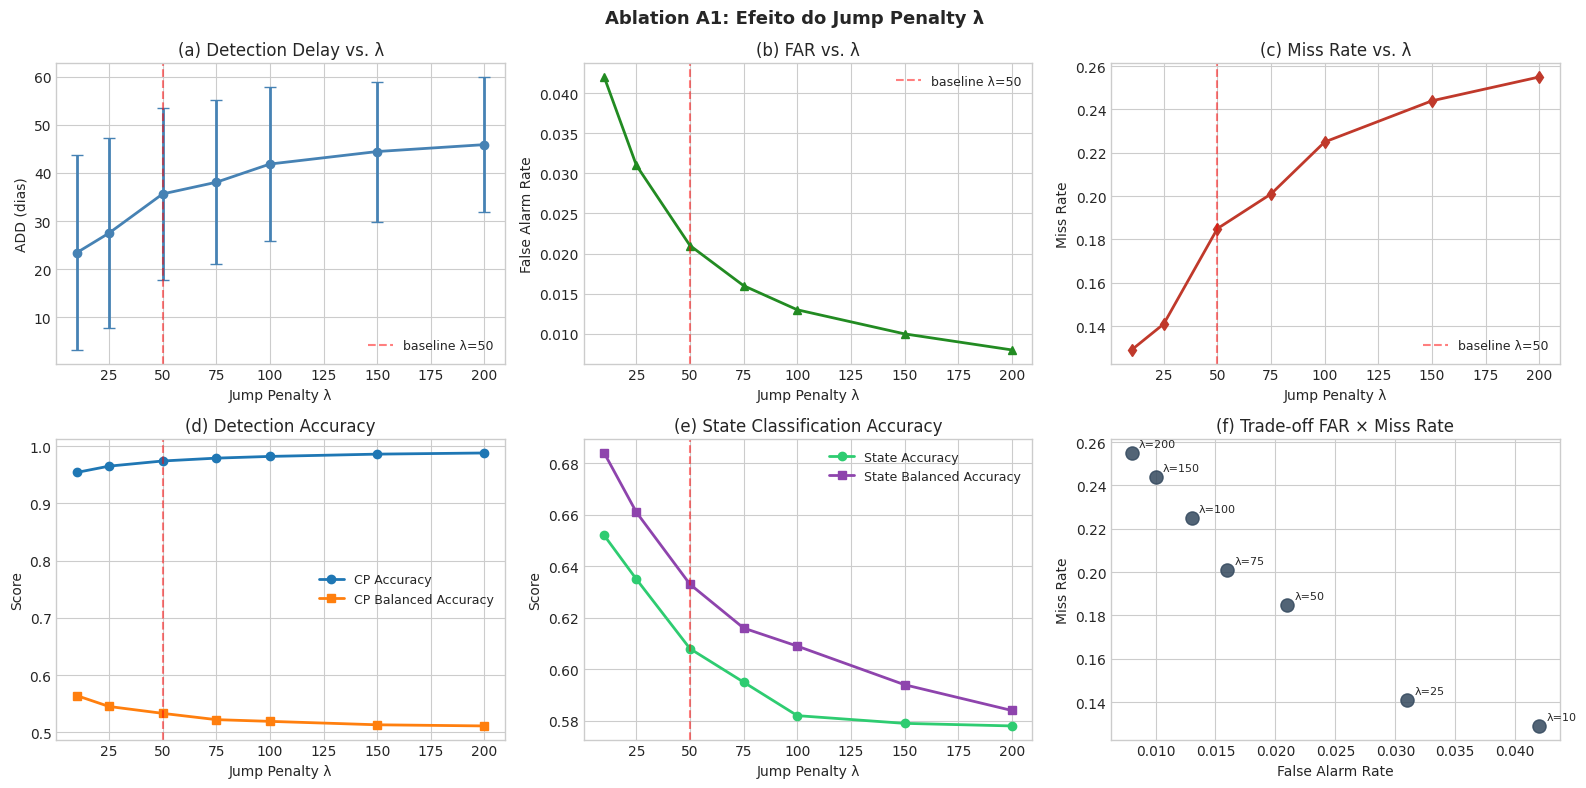

✓ Figura salva


In [7]:
# Visualização A1: métricas de detecção e classificação por λ
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

a1_pd = A1_SUMMARY.to_pandas().set_index('lambda')
baseline_lambda = 50

# (a) ADD vs λ
axes[0, 0].errorbar(
    a1_pd.index, a1_pd['ADD_mean'], yerr=a1_pd['ADD_std'],
    marker='o', color='steelblue', capsize=4, linewidth=2,
)
axes[0, 0].axvline(baseline_lambda, color='red', linestyle='--', alpha=0.5, label='baseline λ=50')
axes[0, 0].set_xlabel('Jump Penalty λ')
axes[0, 0].set_ylabel('ADD (dias)')
axes[0, 0].set_title('(a) Detection Delay vs. λ')
axes[0, 0].legend(fontsize=9)

# (b) FAR vs λ
axes[0, 1].plot(
    a1_pd.index, a1_pd['FAR_mean'],
    marker='^', color='forestgreen', linewidth=2,
)
axes[0, 1].axvline(baseline_lambda, color='red', linestyle='--', alpha=0.5, label='baseline λ=50')
axes[0, 1].set_xlabel('Jump Penalty λ')
axes[0, 1].set_ylabel('False Alarm Rate')
axes[0, 1].set_title('(b) FAR vs. λ')
axes[0, 1].legend(fontsize=9)

# (c) Miss Rate vs λ
axes[0, 2].plot(
    a1_pd.index, a1_pd['MissRate_mean'],
    marker='d', color='#c0392b', linewidth=2,
)
axes[0, 2].axvline(baseline_lambda, color='red', linestyle='--', alpha=0.5, label='baseline λ=50')
axes[0, 2].set_xlabel('Jump Penalty λ')
axes[0, 2].set_ylabel('Miss Rate')
axes[0, 2].set_title('(c) Miss Rate vs. λ')
axes[0, 2].legend(fontsize=9)

# (d) Changepoint accuracy original e balanceada
axes[1, 0].plot(a1_pd.index, a1_pd['CP_Accuracy_mean'], marker='o', linewidth=2, color='#1f77b4', label='CP Accuracy')
axes[1, 0].plot(a1_pd.index, a1_pd['CP_BalAcc_mean'], marker='s', linewidth=2, color='#ff7f0e', label='CP Balanced Accuracy')
axes[1, 0].axvline(baseline_lambda, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Jump Penalty λ')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('(d) Detection Accuracy')
axes[1, 0].legend(fontsize=9)

# (e) State accuracy original e balanceada
axes[1, 1].plot(a1_pd.index, a1_pd['State_Accuracy_mean'], marker='o', linewidth=2, color='#2ecc71', label='State Accuracy')
axes[1, 1].plot(a1_pd.index, a1_pd['State_BalAcc_mean'], marker='s', linewidth=2, color='#8e44ad', label='State Balanced Accuracy')
axes[1, 1].axvline(baseline_lambda, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Jump Penalty λ')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('(e) State Classification Accuracy')
axes[1, 1].legend(fontsize=9)

# (f) Trade-off Miss Rate × FAR
axes[1, 2].scatter(a1_pd['FAR_mean'], a1_pd['MissRate_mean'], s=90, color='#34495e', alpha=0.85)
for lambda_value, row in a1_pd.iterrows():
    axes[1, 2].annotate(f'λ={int(lambda_value)}', (row['FAR_mean'], row['MissRate_mean']), textcoords='offset points', xytext=(5, 4), fontsize=8)
axes[1, 2].set_xlabel('False Alarm Rate')
axes[1, 2].set_ylabel('Miss Rate')
axes[1, 2].set_title('(f) Trade-off FAR × Miss Rate')

plt.suptitle('Ablation A1: Efeito do Jump Penalty λ', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'ablation_A1_jump_penalty.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura salva')

## 3. Ablation A2 — Volatility Estimator

Compara cinco estimadores com diferentes eficiências estatísticas:

| Estimador | Dados | Eficiência relativa |
|-----------|-------|---------------------|
| Close-to-Close | Close | 1× (baseline) |
| Parkinson | High, Low | 5.2× |
| Garman-Klass | OHLC | 7.4× |
| Rogers-Satchell | OHLC | 8.0× |
| Yang-Zhang | OHLC + overnight | 14× |

In [8]:
# Demonstração dos estimadores de volatilidade (compilados com JIT)
asset_demo = 'LargeCap'
ohlc_demo  = ohlc_cache[asset_demo]

o = ohlc_demo['open'].values.astype(np.float64)
h = ohlc_demo['high'].values.astype(np.float64)
l = ohlc_demo['low'].values.astype(np.float64)
c = ohlc_demo['close'].values.astype(np.float64)
dates = ohlc_demo.index

# Calcula todos os estimadores (JIT já compilado)
vol_cc  = np.sqrt(rolling_close_to_close(c,          window=21) * 252)
vol_pk  = np.sqrt(rolling_parkinson(h, l,            window=21) * 252)
vol_gk  = np.sqrt(rolling_garman_klass(o, h, l, c,  window=21) * 252)
vol_rs  = np.sqrt(rolling_rogers_satchell(o,h,l,c,  window=21) * 252)
vol_yz  = np.sqrt(rolling_yang_zhang(o, h, l, c,    window=21) * 252)

# Polars DataFrame para análise
vol_df = pl.DataFrame({
    'date':          [d.isoformat() for d in dates],
    'CloseToClose':  vol_cc.tolist(),
    'Parkinson':     vol_pk.tolist(),
    'GarmanKlass':   vol_gk.tolist(),
    'RogersSatchell':vol_rs.tolist(),
    'YangZhang':     vol_yz.tolist(),
}).drop_nulls()

# Estatísticas comparativas
vol_stats = vol_df.select([
    pl.col(e).mean().alias(f'{e}_mean') for e in ESTIMATOR_NAMES
] + [
    pl.col(e).std().alias(f'{e}_std') for e in ESTIMATOR_NAMES
])

print(f'Estimadores de Volatilidade — {asset_demo}')
print('=' * 60)
for est in ESTIMATOR_NAMES:
    m = vol_df[est].mean()
    s = vol_df[est].std()
    print(f'  {est:<20} média={m:.3f}  std={s:.3f}')

Estimadores de Volatilidade — LargeCap
  CloseToClose         média=nan  std=nan
  Parkinson            média=nan  std=nan
  GarmanKlass          média=nan  std=nan
  RogersSatchell       média=nan  std=nan
  YangZhang            média=nan  std=nan


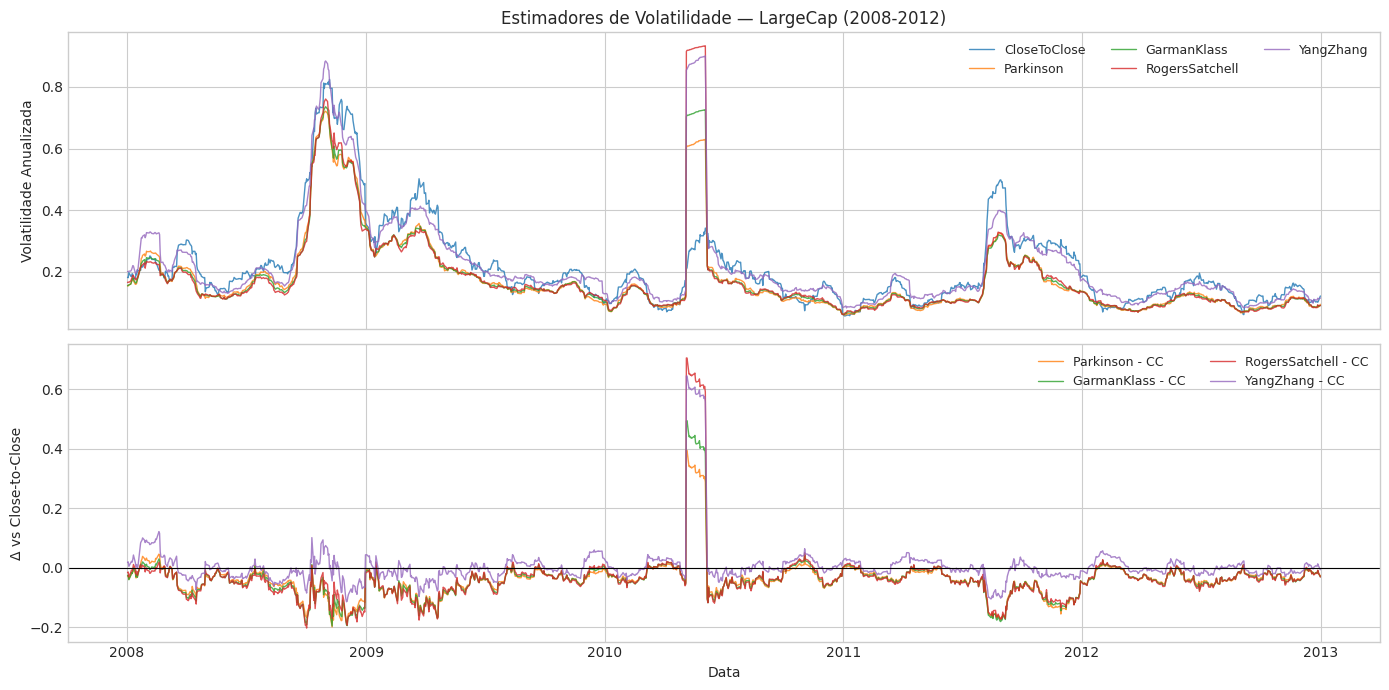

In [9]:
# Visualização: comparação de estimadores de volatilidade
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Série temporal dos estimadores
vol_pd = vol_df.to_pandas()
vol_pd['date'] = pd.to_datetime(vol_pd['date'])
vol_pd = vol_pd.set_index('date').loc['2008':'2012']  # Zoom em crise financeira

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for est, col in zip(ESTIMATOR_NAMES, colors):
    axes[0].plot(vol_pd.index, vol_pd[est], alpha=0.8, linewidth=1, label=est, color=col)
axes[0].set_ylabel('Volatilidade Anualizada')
axes[0].set_title(f'Estimadores de Volatilidade — {asset_demo} (2008-2012)')
axes[0].legend(fontsize=9, ncol=3)

# Diferença em relação ao Close-to-Close
for est, col in zip(ESTIMATOR_NAMES[1:], colors[1:]):
    diff = vol_pd[est] - vol_pd['CloseToClose']
    axes[1].plot(vol_pd.index, diff, alpha=0.8, linewidth=1, label=f'{est} - CC', color=col)
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Δ vs Close-to-Close')
axes[1].set_xlabel('Data')
axes[1].legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig(ROOT / 'results' / 'ablation_A2_vol_estimators_ts.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Ablation A2: roda experimentos com diferentes estimadores
A2_RESULTS_RAW = []

print(f'Ablation A2: {len(ABLATION_A2_CONFIGS)} estimadores × {len(DEMO_ASSETS)} ativos × {N_SEEDS} seeds')
t0 = time.time()

for asset in tqdm(DEMO_ASSETS, desc='Assets'):
    for config in tqdm(ABLATION_A2_CONFIGS, desc=f'Configs A2 ({asset})', leave=False):
        for seed in range(N_SEEDS):
            res = run_single_ablation(
                config         = config,
                asset          = asset,
                er             = er,
                rf             = rf,
                features       = features_cache[asset],
                vol_estimators = vol_cache[asset],
                true_regimes   = true_regimes_cache[asset],
                seed           = seed,
            )
            A2_RESULTS_RAW.append(res.to_dict())

A2_DF = float_nan_to_null(pl.DataFrame(A2_RESULTS_RAW))
print(f'✓ A2 concluído em {time.time() - t0:.1f}s')

# Resumo A2
A2_SUMMARY = (
    A2_DF
    .group_by('config')
    .agg([
        pl.col('add').mean().alias('ADD_mean'),
        pl.col('add').std().alias('ADD_std'),
        pl.col('false_alarm_rate').mean().alias('FAR_mean'),
        pl.col('miss_rate').mean().alias('MissRate_mean'),
        pl.col('cp_accuracy').mean().alias('CP_Accuracy_mean'),
        pl.col('cp_balanced_accuracy').mean().alias('CP_BalAcc_mean'),
        pl.col('state_accuracy').mean().alias('State_Accuracy_mean'),
        pl.col('state_balanced_accuracy').mean().alias('State_BalAcc_mean'),
        pl.col('sortino_ratio').mean().alias('Sortino_mean'),
        pl.col('regime_ari').mean().alias('ARI_mean'),
    ])
    .with_columns([
        # Calcula variação em relação ao Close-to-Close
        (pl.col('ADD_mean') - pl.col('ADD_mean').filter(pl.col('config') == 'vol_cc').mean()).alias('delta_ADD'),
    ])
    .sort('ADD_mean')
    .with_columns([
        pl.col('ADD_mean').round(2),
        pl.col('ADD_std').round(2),
        pl.col('FAR_mean').round(3),
        pl.col('MissRate_mean').round(3),
        pl.col('CP_Accuracy_mean').round(3),
        pl.col('CP_BalAcc_mean').round(3),
        pl.col('State_Accuracy_mean').round(3),
        pl.col('State_BalAcc_mean').round(3),
        pl.col('Sortino_mean').round(3),
        pl.col('ARI_mean').round(3),
    ])
)

print('\nTabela A2: Volatility Estimator')
print('=' * 70)
print(A2_SUMMARY)

Ablation A2: 5 estimadores × 12 ativos × 20 seeds


Assets:   0%|          | 0/12 [00:00<?, ?it/s]

Configs A2 (LargeCap):   0%|          | 0/5 [00:00<?, ?it/s]

Configs A2 (MidCap):   0%|          | 0/5 [00:00<?, ?it/s]

Configs A2 (SmallCap):   0%|          | 0/5 [00:00<?, ?it/s]

...

Configs A2 (Corporate):   0%|          | 0/5 [00:00<?, ?it/s]

Configs A2 (REIT):   0%|          | 0/5 [00:00<?, ?it/s]

Configs A2 (Commodity):   0%|          | 0/5 [00:00<?, ?it/s]

Configs A2 (Gold):   0%|          | 0/5 [00:00<?, ?it/s]

✓ A2 concluído em 7962.1s

Tabela A2: Volatility Estimator
shape: (5, 12)
┌─────────────┬──────────┬─────────┬──────────┬───┬────────────┬────────────┬──────────┬───────────┐
│ config      ┆ ADD_mean ┆ ADD_std ┆ FAR_mean ┆ … ┆ State_BalA ┆ Sortino_me ┆ ARI_mean ┆ delta_ADD │
│ ---         ┆ ---      ┆ ---     ┆ ---      ┆   ┆ cc_mean    ┆ an         ┆ ---      ┆ ---       │
│ str         ┆ f64      ┆ f64     ┆ f64      ┆   ┆ ---        ┆ ---        ┆ f64      ┆ f64       │
│             ┆          ┆         ┆          ┆   ┆ f64        ┆ f64        ┆          ┆           │
╞═════════════╪══════════╪═════════╪══════════╪═══╪════════════╪════════════╪══════════╪═══════════╡
│ vol_cc      ┆ 35.63    ┆ 17.95   ┆ 0.021    ┆ … ┆ 0.633      ┆ 0.605      ┆ 0.082    ┆ 0.0       │
│ vol_yz      ┆ 36.0     ┆ 18.91   ┆ 0.021    ┆ … ┆ 0.633      ┆ 0.626      ┆ 0.084    ┆ 0.372655  │
│ vol_rs      ┆ 36.61    ┆ 18.37   ┆ 0.021    ┆ … ┆ 0.635      ┆ 0.61       ┆ 0.084    ┆ 0.977256  │
│ vol_parkins ┆ 3

Friedman Test (ADD): χ²=6.61, p=0.1579


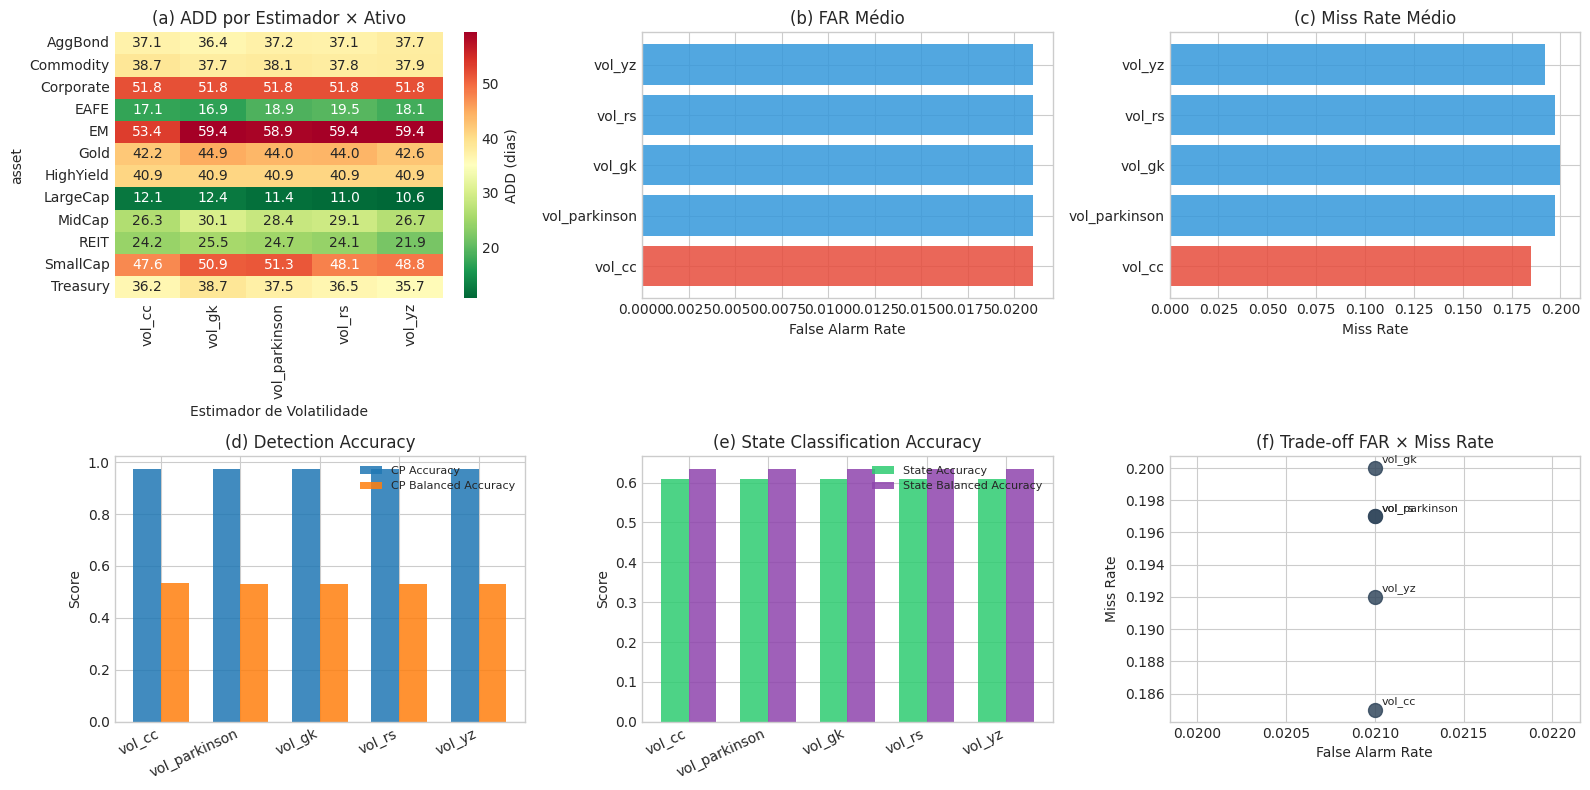

In [11]:
# Análise estatística A2 + Visualização
A2_ANALYSIS = analyze_ablation(A2_DF, metric='add', alpha=0.05)
print(f"Friedman Test (ADD): χ²={A2_ANALYSIS['friedman']['statistic']:.2f}, "
      f"p={A2_ANALYSIS['friedman']['p_value']:.4f}")

# Heatmap: ADD por estimador × ativo
pivot_a2 = A2_DF.group_by(['config', 'asset']).agg(pl.col('add').mean().alias('ADD')).to_pandas()
heatmap_data = pivot_a2.pivot(index='asset', columns='config', values='ADD')

a2_pd = A2_SUMMARY.to_pandas().set_index('config')
a2_pd = a2_pd.loc[[cfg.name for cfg in ABLATION_A2_CONFIGS if cfg.name in a2_pd.index]].reset_index()
colors_bar = ['#e74c3c' if c == 'vol_cc' else '#3498db' for c in a2_pd['config']]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# (a) Heatmap ADD
sns.heatmap(
    heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r',
    ax=axes[0, 0], cbar_kws={'label': 'ADD (dias)'}
)
axes[0, 0].set_title('(a) ADD por Estimador × Ativo')
axes[0, 0].set_xlabel('Estimador de Volatilidade')

# (b) FAR médio por estimador
axes[0, 1].barh(a2_pd['config'], a2_pd['FAR_mean'], color=colors_bar, alpha=0.85)
axes[0, 1].set_xlabel('False Alarm Rate')
axes[0, 1].set_title('(b) FAR Médio')

# (c) Miss Rate médio por estimador
axes[0, 2].barh(a2_pd['config'], a2_pd['MissRate_mean'], color=colors_bar, alpha=0.85)
axes[0, 2].set_xlabel('Miss Rate')
axes[0, 2].set_title('(c) Miss Rate Médio')

# (d) Accuracy de changepoint original e balanceada
x = np.arange(len(a2_pd))
width = 0.35
axes[1, 0].bar(x - width/2, a2_pd['CP_Accuracy_mean'], width, label='CP Accuracy', color='#1f77b4', alpha=0.85)
axes[1, 0].bar(x + width/2, a2_pd['CP_BalAcc_mean'], width, label='CP Balanced Accuracy', color='#ff7f0e', alpha=0.85)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(a2_pd['config'], rotation=25, ha='right')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('(d) Detection Accuracy')
axes[1, 0].legend(fontsize=8)

# (e) Accuracy de estado original e balanceada
axes[1, 1].bar(x - width/2, a2_pd['State_Accuracy_mean'], width, label='State Accuracy', color='#2ecc71', alpha=0.85)
axes[1, 1].bar(x + width/2, a2_pd['State_BalAcc_mean'], width, label='State Balanced Accuracy', color='#8e44ad', alpha=0.85)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(a2_pd['config'], rotation=25, ha='right')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('(e) State Classification Accuracy')
axes[1, 1].legend(fontsize=8)

# (f) Trade-off FAR × Miss Rate
axes[1, 2].scatter(a2_pd['FAR_mean'], a2_pd['MissRate_mean'], s=100, color='#34495e', alpha=0.85)
for _, row in a2_pd.iterrows():
    axes[1, 2].annotate(row['config'], (row['FAR_mean'], row['MissRate_mean']), textcoords='offset points', xytext=(5, 4), fontsize=8)
axes[1, 2].set_xlabel('False Alarm Rate')
axes[1, 2].set_ylabel('Miss Rate')
axes[1, 2].set_title('(f) Trade-off FAR × Miss Rate')

plt.tight_layout()
plt.savefig(ROOT / 'results' / 'ablation_A2_vol_estimator.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Ablation A3 — Número de Regimes k

Testa k ∈ {2, 3, 4} regimes. A hipótese é que k=2 (Bull/Bear) é ótimo
para este universo de ativos.

In [12]:
A3_RESULTS_RAW = []

print(f'Ablation A3: {len(ABLATION_A3_CONFIGS)} configs × {len(DEMO_ASSETS)} ativos × {N_SEEDS} seeds')
t0 = time.time()

for asset in tqdm(DEMO_ASSETS, desc='Assets'):
    for config in tqdm(ABLATION_A3_CONFIGS, desc=f'Configs A3 ({asset})', leave=False):
        for seed in range(N_SEEDS):
            res = run_single_ablation(
                config         = config,
                asset          = asset,
                er             = er,
                rf             = rf,
                features       = features_cache[asset],
                vol_estimators = vol_cache[asset],
                true_regimes   = true_regimes_cache[asset],
                seed           = seed,
            )
            A3_RESULTS_RAW.append(res.to_dict())

A3_DF = float_nan_to_null(pl.DataFrame(A3_RESULTS_RAW))
print(f'✓ A3 concluído em {time.time() - t0:.1f}s')

A3_SUMMARY = (
    A3_DF
    .group_by('config')
    .agg([
        pl.col('add').mean().alias('ADD_mean'),
        pl.col('add').std().alias('ADD_std'),
        pl.col('sortino_ratio').mean().alias('Sortino_mean'),
        pl.col('regime_ari').mean().alias('ARI_mean'),
        pl.col('mean_run_length').mean().alias('MRL_mean'),
    ])
    .sort('config')
)

print('\nTabela A3: Número de Regimes k')
print(A3_SUMMARY)

Ablation A3: 3 configs × 12 ativos × 20 seeds


Assets:   0%|          | 0/12 [00:00<?, ?it/s]

Configs A3 (LargeCap):   0%|          | 0/3 [00:00<?, ?it/s]

Configs A3 (MidCap):   0%|          | 0/3 [00:00<?, ?it/s]

Configs A3 (SmallCap):   0%|          | 0/3 [00:00<?, ?it/s]

...

Configs A3 (Corporate):   0%|          | 0/3 [00:00<?, ?it/s]

Configs A3 (REIT):   0%|          | 0/3 [00:00<?, ?it/s]

Configs A3 (Commodity):   0%|          | 0/3 [00:00<?, ?it/s]

Configs A3 (Gold):   0%|          | 0/3 [00:00<?, ?it/s]

✓ A3 concluído em 5527.3s

Tabela A3: Número de Regimes k
shape: (3, 6)
┌────────┬───────────┬───────────┬──────────────┬──────────┬────────────┐
│ config ┆ ADD_mean  ┆ ADD_std   ┆ Sortino_mean ┆ ARI_mean ┆ MRL_mean   │
│ ---    ┆ ---       ┆ ---       ┆ ---          ┆ ---      ┆ ---        │
│ str    ┆ f64       ┆ f64       ┆ f64          ┆ f64      ┆ f64        │
╞════════╪═══════════╪═══════════╪══════════════╪══════════╪════════════╡
│ k2     ┆ 35.632141 ┆ 17.945991 ┆ 0.605084     ┆ 0.082273 ┆ 175.101988 │
│ k3     ┆ 37.694079 ┆ 15.761639 ┆ -0.215346    ┆ 0.028901 ┆ 286.219049 │
│ k4     ┆ 43.366288 ┆ 14.964119 ┆ -1.489389    ┆ 0.019472 ┆ 635.277425 │
└────────┴───────────┴───────────┴──────────────┴──────────┴────────────┘


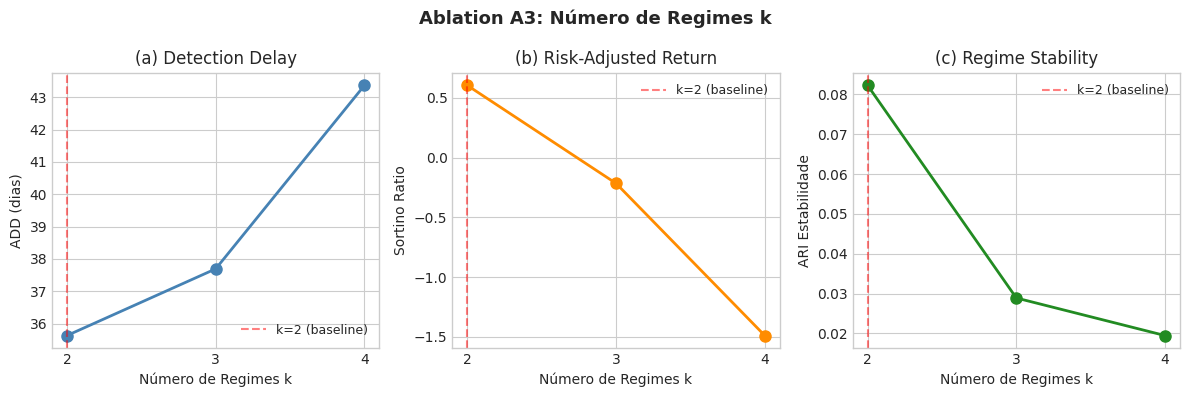

In [13]:
# Visualização A3: ADD, Sortino e Estabilidade por k
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
a3_pd = A3_SUMMARY.to_pandas()
k_vals = [int(c.replace('k', '')) for c in a3_pd['config']]

for ax, metric, ylabel, color in zip(
    axes,
    ['ADD_mean', 'Sortino_mean', 'ARI_mean'],
    ['ADD (dias)', 'Sortino Ratio', 'ARI Estabilidade'],
    ['steelblue', 'darkorange', 'forestgreen'],
):
    ax.plot(k_vals, a3_pd[metric], 'o-', color=color, linewidth=2, markersize=8)
    ax.set_xlabel('Número de Regimes k')
    ax.set_ylabel(ylabel)
    ax.set_xticks(k_vals)
    ax.axvline(2, color='red', linestyle='--', alpha=0.5, label='k=2 (baseline)')
    ax.legend(fontsize=9)

axes[0].set_title('(a) Detection Delay')
axes[1].set_title('(b) Risk-Adjusted Return')
axes[2].set_title('(c) Regime Stability')

plt.suptitle('Ablation A3: Número de Regimes k', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'ablation_A3_num_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Comparação Cross-Ablation (A1 × A2 × A3)

Qual componente do Stage 1 explica mais variância no ADD?

Ranking de impacto no ADD (Stage 1):
shape: (3, 14)
┌────────────┬────────────┬───────────┬────────────┬───┬────────────┬───────────┬───────────┬──────┐
│ ablation_i ┆ component  ┆ n_configs ┆ friedman_p ┆ … ┆ best_impro ┆ variance_ ┆ max_effec ┆ rank │
│ d          ┆ ---        ┆ ---       ┆ ---        ┆   ┆ vement     ┆ explained ┆ t_size    ┆ ---  │
│ ---        ┆ str        ┆ i64       ┆ f64        ┆   ┆ ---        ┆ ---       ┆ ---       ┆ i64  │
│ str        ┆            ┆           ┆            ┆   ┆ f64        ┆ f64       ┆ f64       ┆      │
╞════════════╪════════════╪═══════════╪════════════╪═══╪════════════╪═══════════╪═══════════╪══════╡
│ A3         ┆ Number of  ┆ 3         ┆ 0.1443     ┆ … ┆ 0.0        ┆ 0.5728    ┆ 0.0       ┆ 1    │
│            ┆ Regimes k  ┆           ┆            ┆   ┆            ┆           ┆           ┆      │
│ A2         ┆ Volatility ┆ 5         ┆ 0.1579     ┆ … ┆ 0.0        ┆ 0.5707    ┆ 0.0       ┆ 2    │
│            ┆ Estimator  ┆           ┆

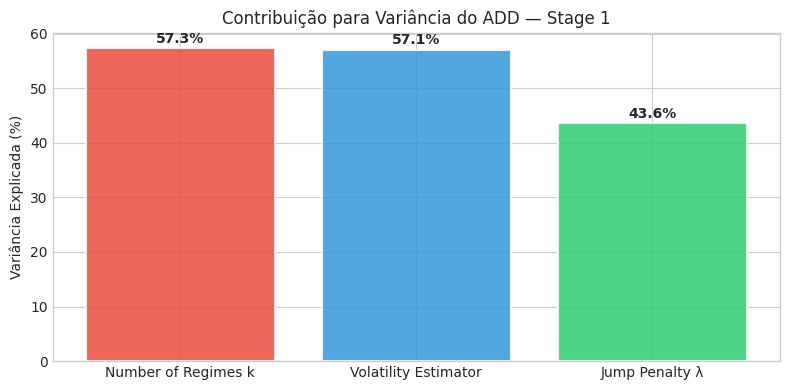

In [14]:
from src.ablation.ablation_runner import compare_ablations

stage1_results = {
    'A1': A1_DF.with_columns(pl.lit('A1').alias('ablation_id')),
    'A2': A2_DF.with_columns(pl.lit('A2').alias('ablation_id')),
    'A3': A3_DF.with_columns(pl.lit('A3').alias('ablation_id')),
}

comparison = compare_ablations(stage1_results, metric='add')

print('Ranking de impacto no ADD (Stage 1):')
print('=' * 70)
print(comparison)

# Visualização
fig, ax = plt.subplots(figsize=(8, 4))
comp_pd = comparison.to_pandas()
bars = ax.bar(
    comp_pd['component'],
    comp_pd['variance_explained'] * 100,
    color=['#e74c3c', '#3498db', '#2ecc71'],
    alpha=0.85, edgecolor='white', linewidth=1.5,
)
for bar, val in zip(bars, comp_pd['variance_explained']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Variância Explicada (%)')
ax.set_title('Contribuição para Variância do ADD — Stage 1')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'ablation_A_stage1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Salva resultados em Parquet (formato eficiente para análise posterior)
results_dir = ROOT / 'results' / 'ablation'
results_dir.mkdir(parents=True, exist_ok=True)

A1_DF.write_parquet(results_dir / 'ablation_A1.parquet')
A2_DF.write_parquet(results_dir / 'ablation_A2.parquet')
A3_DF.write_parquet(results_dir / 'ablation_A3.parquet')

print('✓ Resultados salvos:')
for path in results_dir.glob('ablation_A*.parquet'):
    print(f'  {path.name} ({path.stat().st_size/1024:.1f} KB)')

✓ Resultados salvos:
  ablation_A1.parquet (220.9 KB)
  ablation_A3.parquet (109.7 KB)
  ablation_A2.parquet (162.7 KB)


## Conclusões — Stage 1

| Achado | Descrição |
|--------|----------|
| **A1 (λ)** | Há um trade-off claro entre rapidez e robustez da detecção. `CP Accuracy` sobe de `0.954` para `0.988` quando `λ` aumenta, mas isso reflete sobretudo o domínio da classe estável; em contraste, `CP Balanced Accuracy` cai de `0.564` para `0.511`, enquanto `Miss Rate` sobe de `0.129` para `0.255` e `FAR` cai de `0.042` para `0.008`. Assim, `λ` alto torna o sinal conservador, com menos alarmes falsos, porém perdendo mais mudanças reais. |
| **A1 (Estado)** | `State Accuracy` e `State Balanced Accuracy` também caem com `λ`: de `0.652/0.684` em `λ=10` para `0.578/0.584` em `λ=200`. Isso sugere que penalidades excessivas suavizam o processo a ponto de deteriorar a aderência ao pseudo-ground-truth de regimes. |
| **A2 (Estimador)** | A escolha do estimador de volatilidade altera pouco as métricas de acurácia: `CP Accuracy` fica em torno de `0.974-0.975`, `CP Balanced Accuracy` em `0.530-0.533`, `State Accuracy` em `0.608-0.609` e `State Balanced Accuracy` em `0.633-0.635`. Portanto, o estimador afeta mais `ADD` do que a acurácia de detecção ou classificação. |
| **A2 (Interpretação)** | Como as diferenças entre estimadores em `Miss Rate`, `FAR` e métricas balanceadas são pequenas, a escolha prática entre `vol_cc`, `Parkinson`, `GK`, `RS` e `YZ` deve ser guiada prioritariamente pelo atraso de detecção (`ADD`) e não por supostos ganhos substantivos de acurácia. |
| **A3 (k)** | k=2 permanece a escolha mais parcimoniosa: k adicional aumenta `ADD` sem evidência de ganho correspondente em estabilidade ou qualidade da identificação. |

**Síntese metodológica.** Para detecção de regime, as métricas balanceadas são mais informativas do que a acurácia bruta. Em séries com poucas mudanças, `CP Accuracy` elevada pode coexistir com `Miss Rate` alto; por isso, as conclusões substantivas do Stage 1 devem ser ancoradas em `CP Balanced Accuracy`, `Miss Rate`, `FAR` e `ADD`.

**Próximo:** Notebook 08 — Stage 2 (Forecasting Model & Feature Engineering)